# Scenic Potential and Accessibility Analysis — GB, North KP, and AJK

This notebook computes the Scenic Potential Index (SPI) and Accessibility Index (AI)
for tehsils in Gilgit-Baltistan, northern Khyber Pakhtunkhwa, and Azad Jammu & Kashmir,
then runs the full statistical analysis described in the project proposal.

**Workflow:**
1. Load preprocessed, grid-aligned raster inputs from `data/interim/`
2. Compute SPI and AI rasters and save to `data/processed/`
3. Compute tehsil-level zonal statistics
4. Run descriptive statistics, spatial autocorrelation, OLS regression, priority ranking, and sensitivity analysis
5. Export final dataset to `outputs/` and `data/processed/`

Run all cells top to bottom — no manual edits required.

## 1. Imports and Setup

In [1]:
import re
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from scipy.ndimage import uniform_filter, distance_transform_edt
from rasterio.features import rasterize, geometry_mask

warnings.filterwarnings('ignore')

try:
    from libpysal.weights import Queen
    from libpysal.weights.spatial_lag import lag_spatial
    from esda.moran import Moran, Moran_Local
    SPATIAL_BACKEND = 'libpysal'
except ImportError:
    SPATIAL_BACKEND = 'fallback'

try:
    import statsmodels.api as sm
    from statsmodels.stats.stattools import jarque_bera
    from statsmodels.stats.diagnostic import het_breuschpagan
    STATS_BACKEND = 'statsmodels'
except ImportError:
    STATS_BACKEND = 'fallback'

print(f'Spatial backend: {SPATIAL_BACKEND}')
print(f'Stats backend:   {STATS_BACKEND}')

Spatial backend: libpysal
Stats backend:   statsmodels


In [2]:
# Resolve project root regardless of where Jupyter was launched
cwd = Path.cwd()
if cwd.name == 'spi_gb_north':
    root = cwd
elif (cwd / 'spi_gb_north').exists():
    root = cwd / 'spi_gb_north'
elif (cwd / 'sds' / 'spi_gb_north').exists():
    root = cwd / 'sds' / 'spi_gb_north'
else:
    root = next((p for p in [cwd, *cwd.parents]
                 if (p / 'data').exists() and (p / 'outputs').exists()), cwd)

interim   = root / 'data' / 'interim'
processed = root / 'data' / 'processed'
outputs   = root / 'outputs'
processed.mkdir(parents=True, exist_ok=True)
outputs.mkdir(parents=True, exist_ok=True)

# SPI formula: SPI = 0.35*Relief + 0.25*Forest + 0.20*Water + 0.20*Snow
# Relief = Z(0.5*TPI_z + 0.5*TRI_z)
SPI_WEIGHTS = {'Relief': 0.35, 'Forest': 0.25, 'Water': 0.20, 'Snow': 0.20}
assert abs(sum(SPI_WEIGHTS.values()) - 1.0) < 1e-9

data_paths = {
    'dem':            interim / 'dem_32643_100m.tif',
    'landcover':      interim / 'landcover_2024_32643_100m.tif',
    'forest_mask':    interim / 'forest_mask_32643_100m.tif',
    'water_mask':     interim / 'water_mask_32643_100m.tif',
    # tpi_new outputs — use zscore (clipped ±300m + z-scored), not raw
    'tpi_raw':        interim / 'tpi_products' / 'tpi_raw_radius2_32643_100m.tif',
    'tpi_zscore':     interim / 'tpi_products' / 'tpi_zscore_radius2_32643_100m.tif',
    'tpi_landforms':  interim / 'tpi_products' / 'tpi_landforms_radius2_32643_100m.tif',
    'tri':            interim / 'tri_32643_100m.tif',
    'snow_days':      interim / 'snow_aligned_32643_100m' / 'snow_days_aligned_32643_100m.tif',
    'snow_frequency': interim / 'snow_aligned_32643_100m' / 'snow_frequency_aligned_32643_100m.tif',
    'roads_distance': interim / 'dist_to_roads_all_32643_100m.tif',
    'aoi_boundary':   interim / 'aoi_boundary_32643.gpkg',
    'admin_boundaries': root / 'data' / 'raw' / 'admin_boundaries' / 'geoBoundaries-PAK-ADM3.geojson',
    'tehsils':        interim / 'tehsils_aoi_32643.gpkg',
    'roads':          interim / 'roads_all_32643.gpkg',
    # Optional helper list used only for name filtering; not required if absent.
    'tehsil_list':    root.parent / 'project' / 'aoi_tehsils_list.txt',
}

required_keys = [k for k in data_paths if k != 'tehsil_list']
missing_files = [f"{k}: {data_paths[k]}" for k in required_keys if not data_paths[k].exists()]
if missing_files:
    print('❌ Missing required data files:')
    for f in missing_files:
        print(f'  {f}')
    raise FileNotFoundError('Cannot proceed without all preprocessed data files')
else:
    print('✓ All required data files found')
    print(f'\nData directory: {interim}')
    print(f'Output directory: {processed}')
    print(f'\nSPI Weights (sum={sum(SPI_WEIGHTS.values())}):')
    for k, v in SPI_WEIGHTS.items():
        print(f'  {k}: {v:.0%}')

✓ All required data files found

Data directory: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\interim
Output directory: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\processed

SPI Weights (sum=1.0):
  Relief: 35%
  Forest: 25%
  Water: 20%
  Snow: 20%


## 2. Load Input Rasters

In [3]:
def load_raster_data(path, name):
    """Load raster data and return array, metadata"""
    with rasterio.open(path) as src:
        data = src.read(1)
        meta = {
            'crs': src.crs,
            'transform': src.transform,
            'shape': data.shape,
            'nodata': src.nodata,
            'dtype': data.dtype,
            'bounds': src.bounds
        }
        
        # Print basic info
        finite_count = np.isfinite(data).sum() if np.issubdtype(data.dtype, np.floating) else (data != src.nodata).sum()
        total_pixels = data.size
        coverage_pct = (finite_count / total_pixels) * 100
        
        print(f'✓ {name}: {data.shape} | {data.dtype} | {coverage_pct:.1f}% valid pixels')
        
        return data, meta

# Load all raster data layers
print('Loading raster data layers...')
rasters = {}
metadata = {}

# Core SPI components
rasters['dem'], metadata['dem'] = load_raster_data(data_paths['dem'], 'DEM')
rasters['tpi_zscore'], metadata['tpi_zscore'] = load_raster_data(data_paths['tpi_zscore'], 'TPI Z-score')
rasters['forest_mask'], metadata['forest_mask'] = load_raster_data(data_paths['forest_mask'], 'Forest Mask')
rasters['water_mask'], metadata['water_mask'] = load_raster_data(data_paths['water_mask'], 'Water Mask')
rasters['snow_frequency'], metadata['snow_frequency'] = load_raster_data(data_paths['snow_frequency'], 'Snow Frequency')

# Additional layers
rasters['roads_distance'], metadata['roads_distance'] = load_raster_data(data_paths['roads_distance'], 'Roads Distance')
rasters['landcover'], metadata['landcover'] = load_raster_data(data_paths['landcover'], 'Land Cover')

# Load vector data
print('\nLoading vector data...')
vectors = {}
vectors['aoi'] = gpd.read_file(data_paths['aoi_boundary'])
vectors['tehsils'] = gpd.read_file(data_paths['tehsils'])
vectors['roads'] = gpd.read_file(data_paths['roads'])

print(f'✓ AOI boundary: {len(vectors["aoi"])} features')
print(f'✓ Tehsils: {len(vectors["tehsils"])} features')
print(f'✓ Roads: {len(vectors["roads"])} features')

# Verify all rasters have consistent dimensions and CRS
ref_shape = metadata['dem']['shape']
ref_crs = metadata['dem']['crs']

print(f'\nVerifying data consistency...')
print(f'Reference: DEM {ref_shape} | CRS: {ref_crs}')

for name, meta in metadata.items():
    if meta['shape'] != ref_shape:
        print(f'❌ Shape mismatch in {name}: {meta["shape"]} vs {ref_shape}')
    elif meta['crs'] != ref_crs:
        print(f'❌ CRS mismatch in {name}: {meta["crs"]} vs {ref_crs}')
    else:
        print(f'✓ {name}: shape and CRS match')

print('\n✓ All data layers loaded and verified')

Loading raster data layers...
✓ DEM: (4801, 6122) | float32 | 42.9% valid pixels
✓ TPI Z-score: (4801, 6122) | float32 | 42.9% valid pixels
✓ Forest Mask: (4801, 6122) | uint8 | 3.7% valid pixels
✓ Water Mask: (4801, 6122) | uint8 | 10.2% valid pixels
✓ Snow Frequency: (4801, 6122) | float32 | 42.6% valid pixels
✓ Roads Distance: (4801, 6122) | float32 | 42.9% valid pixels
✓ Land Cover: (4801, 6122) | uint8 | 42.9% valid pixels

Loading vector data...
✓ AOI boundary: 1 features
✓ Tehsils: 81 features
✓ Roads: 65462 features

Verifying data consistency...
Reference: DEM (4801, 6122) | CRS: EPSG:32643
✓ dem: shape and CRS match
✓ tpi_zscore: shape and CRS match
✓ forest_mask: shape and CRS match
✓ water_mask: shape and CRS match
✓ snow_frequency: shape and CRS match
✓ roads_distance: shape and CRS match
✓ landcover: shape and CRS match

✓ All data layers loaded and verified


## 3. Scenic Potential Index (SPI)

$$\\text{SPI} = 0.35 \\cdot \\text{Relief} + 0.25 \\cdot \\text{Forest} + 0.20 \\cdot \\text{Water} + 0.20 \\cdot \\text{Snow}$$

Relief is the average of TPI z-score and TRI z-score, re-z-scored after combining. Forest and water are computed as neighborhood density over a 3 km window (30 pixels at 100 m) so a single isolated pixel does not score the same as a dense patch. Glacier pixels (snow frequency > 0.5) are stripped from the water mask to avoid double-counting.

In [4]:
# Extract raster variables for use in SPI and AI calculations
dem         = rasters['dem'].astype(np.float32)
dem_meta    = metadata['dem']
tpi_z       = rasters['tpi_zscore'].astype(np.float32)
forest      = rasters['forest_mask'].astype(np.float32)
water       = rasters['water_mask'].astype(np.float32)
snow        = rasters['snow_frequency'].astype(np.float32)
tri_arr     = None  # Will be loaded if needed

# Try to load TRI raster - needed for complete Relief calculation
if data_paths['tri'].exists():
    with rasterio.open(data_paths['tri']) as src:
        tri_arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            tri_arr[tri_arr == src.nodata] = np.nan
else:
    print('⚠️ TRI raster not found, computing from DEM')
    # Fallback: compute TRI from DEM if tri.tif not available
    px = abs(dem_meta['transform'].a)
    dy, dx = np.gradient(dem, pixel_size_y=px, pixel_size_x=px)
    tri_arr = np.sqrt(dx**2 + dy**2).astype(np.float32)

# Normalize snow to [0,1] if it came in as 0-100
if np.nanmax(snow) > 1.5:
    print(f'Snow range 0-100 detected: normalizing to [0,1]')
    snow /= 100.0

print('✓ Raster variables extracted and ready for computation')

✓ Raster variables extracted and ready for computation


## 2.5 Extract Raster Variables for Computation

In [5]:
def zscore_arr(arr, mask):
    """Z-score over valid pixels; NaN outside mask."""
    vals = arr[mask]
    mu, sigma = vals.mean(), vals.std()
    if sigma < 1e-10:
        sigma = 1.0
    z = np.full_like(arr, np.nan)
    z[mask] = (arr[mask] - mu) / sigma
    return z

def neighborhood_density(binary, mask, window=30):
    """Fraction of valid pixels in a square window that are 1 (30 px = 3 km at 100 m)."""
    num = uniform_filter(np.where(mask, binary, 0.0), size=window, mode='nearest')
    den = uniform_filter(mask.astype(np.float32),     size=window, mode='nearest')
    out = np.where(den > 0, num / den, np.nan)
    out[~mask] = np.nan
    return out.astype(np.float32)

# Remove glaciers from water mask
water = np.where((snow > 0.5) & np.isfinite(water), 0.0, water)

# Valid-pixel mask: pixels that have data in all five input layers
valid = (np.isfinite(tpi_z) & np.isfinite(tri_arr) &
         np.isfinite(forest) & np.isfinite(water) & np.isfinite(snow))

# TRI: clip at P99.9 before z-scoring
tri_clip = np.clip(tri_arr, 0, np.nanpercentile(tri_arr[valid], 99.9))
tri_clip[~valid] = np.nan

# Component z-scores
tri_z    = zscore_arr(tri_clip, valid)
relief_z = zscore_arr(0.5 * tpi_z + 0.5 * tri_z, valid)
forest_z = zscore_arr(neighborhood_density(forest, valid), valid)
water_z  = zscore_arr(neighborhood_density(water,  valid), valid)
snow_z   = zscore_arr(snow, valid)

# Cap z-scores at ±3.5σ to prevent outlier pixels from dominating the weighted sum
for z in (relief_z, forest_z, water_z, snow_z):
    np.clip(z, -3.5, 3.5, out=z)
    z[~valid] = np.nan

spi = (SPI_WEIGHTS['Relief'] * relief_z +
       SPI_WEIGHTS['Forest'] * forest_z +
       SPI_WEIGHTS['Water']  * water_z  +
       SPI_WEIGHTS['Snow']   * snow_z)
spi[~valid] = np.nan

spi_meta = {
    'driver': 'GTiff', 'dtype': 'float32', 'count': 1,
    'width': spi.shape[1], 'height': spi.shape[0],
    'crs': dem_meta['crs'], 'transform': dem_meta['transform'],
    'nodata': np.nan, 'compress': 'lzw',
}
with rasterio.open(processed / 'spi_index.tif', 'w', **spi_meta) as dst:
    dst.write(spi, 1)

print(f'SPI range: [{np.nanmin(spi):.3f}, {np.nanmax(spi):.3f}]  mean={np.nanmean(spi):.3f}')
print(f'Valid pixels: {valid.sum():,}  ({valid.sum() / valid.size * 100:.1f}% of bounding box)')
print(f'Saved: {processed / "spi_index.tif"}')

SPI range: [-1.623, 1.950]  mean=-0.003
Valid pixels: 12,534,668  (42.6% of bounding box)
Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\processed\spi_index.tif


## 4. Accessibility Index (AI)

AI uses exponential decay from road proximity, adjusted for terrain slope:

$$\\text{AI} = e^{-\\lambda \\cdot t}$$

where $t$ is travel time to the nearest road pixel and $\\lambda = \\ln(2)/90$ gives a half-life of 90 minutes. Road speed is taken from OSM highway tags and reduced by a slope modifier (slope > 5°: ×0.8, > 15°: ×0.6, > 25°: ×0.4).

In [6]:
# Slope from DEM
px = abs(dem_meta['transform'].a)
dy, dx = np.gradient(np.where(valid, dem, np.nan), px, px)
slope_deg = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
slope_deg[~valid] = np.nan

slope_mod = np.ones_like(slope_deg)
slope_mod[slope_deg > 5]  = 0.8
slope_mod[slope_deg > 15] = 0.6
slope_mod[slope_deg > 25] = 0.4
slope_mod[~valid] = np.nan

# Rasterize road network with per-type speeds
base_speeds = {
    'motorway': 80, 'trunk': 60, 'primary': 45, 'secondary': 35,
    'tertiary': 25, 'unclassified': 20, 'residential': 15, 'track': 10,
}
roads_gdf = gpd.read_file(data_paths['roads'])
road_type_col = next((c for c in ['highway', 'road_type', 'fclass']
                      if c in roads_gdf.columns), None)
if road_type_col:
    roads_gdf['_spd'] = (roads_gdf[road_type_col]
                         .str.lower().map(base_speeds).fillna(15).astype(np.float32))
else:
    roads_gdf['_spd'] = 15.0

speed_raster = np.full(dem.shape, 3.0, dtype=np.float32)
for spd, grp in roads_gdf.groupby('_spd', sort=True):
    shapes = [(g, spd) for g in grp.geometry if g is not None and not g.is_empty]
    if shapes:
        burned = rasterize(shapes, out_shape=dem.shape,
                           transform=dem_meta['transform'],
                           fill=0, dtype=np.float32, all_touched=True)
        speed_raster[burned > 0] = burned[burned > 0]

adj_speed = np.clip(speed_raster * slope_mod, 1.0, None)
adj_speed[~valid] = np.nan

road_mask = (speed_raster > 3.0) & valid
dist_m    = distance_transform_edt(~road_mask, sampling=(px, px)).astype(np.float32)
spd_mpm   = adj_speed * (1000.0 / 60.0)   # km/h -> m/min
travel_t  = dist_m / np.where(spd_mpm > 0, spd_mpm, np.nan)
travel_t[~valid] = np.nan

lam = np.log(2) / 90.0   # half-life = 90 min
ai  = np.exp(-lam * travel_t).astype(np.float32)
ai[~valid] = np.nan

ai_meta = spi_meta.copy()
with rasterio.open(processed / 'ai_index.tif', 'w', **ai_meta) as dst:
    dst.write(ai, 1)

print(f'Road pixels in AOI: {road_mask.sum():,} ({road_mask.sum() / valid.sum() * 100:.2f}%)')
print(f'AI range: [{np.nanmin(ai):.4f}, {np.nanmax(ai):.4f}]  mean={np.nanmean(ai):.4f}')
print(f'Saved: {processed / "ai_index.tif"}')

Road pixels in AOI: 548,322 (4.37%)
AI range: [0.0000, 1.0000]  mean=0.4553
Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\processed\ai_index.tif


## 5. SPI and AI Raster Maps

These maps show the pixel-level outputs before aggregating to tehsil level.

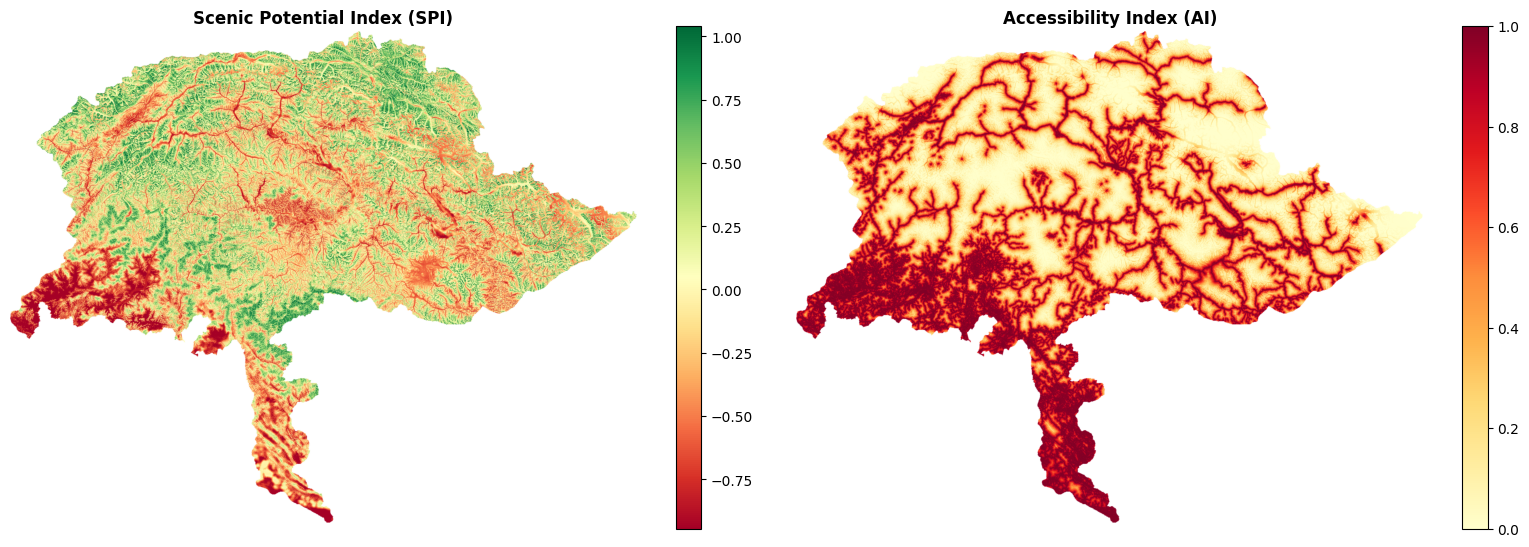

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cmap_spi = plt.cm.RdYlGn.copy(); cmap_spi.set_bad('white')
cmap_ai  = plt.cm.YlOrRd.copy(); cmap_ai.set_bad('white')

ax = axes[0]
im = ax.imshow(np.where(valid, spi, np.nan), cmap=cmap_spi,
               vmin=np.nanpercentile(spi[valid], 2),
               vmax=np.nanpercentile(spi[valid], 98))
ax.set_title('Scenic Potential Index (SPI)', fontweight='bold')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)

ax = axes[1]
im = ax.imshow(np.where(valid, ai, np.nan), cmap=cmap_ai, vmin=0, vmax=1)
ax.set_title('Accessibility Index (AI)', fontweight='bold')
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.75)

plt.tight_layout()
plt.savefig(outputs / '00_spi_ai_rasters.png', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

## 6. Tehsil Zonal Statistics

For each tehsil polygon the mean SPI and AI are extracted from the rasters. The admin boundary file is filtered to the study-area tehsils using a name list; if fewer than 20 names match, the preprocessed tehsil layer is used instead.

In [8]:
def norm_name(s):
    s = str(s).upper().strip()
    return re.sub(r'[^A-Z0-9]+', ' ', s.replace('`', '')).strip()

def load_name_list(path):
    if not path.exists():
        return set()
    text = path.read_text().replace('\\n', '\n')
    return {norm_name(l) for l in text.splitlines()
            if l.strip() and not l.lower().startswith('names of')}

AJK_TEHSILS = {
    'BAGH', 'DHEERKOT', 'BARNALA', 'BHIMBER', 'SAMAHNI', 'HATTIAN BALA',
    'HAVELI', 'KOTLI', 'NAKIAL', 'SEHNSA', 'DUDYAL', 'MIRPUR',
    'MUZAFFARABAD', 'ATHUMQAM', 'ABBASPUR', 'HAJEERA', 'RAWALAKOT', 'PALLANDARI',
}

aoi_names = load_name_list(data_paths['tehsil_list']) | {norm_name(x) for x in AJK_TEHSILS}

admin = gpd.read_file(data_paths['admin_boundaries'])
if admin.crs is None:
    admin = admin.set_crs('EPSG:4326')
admin['geometry'] = admin.geometry.make_valid()
admin = admin[~admin.geometry.is_empty]
admin['_key'] = admin['shapeName'].map(norm_name)

tehsils = admin[admin['_key'].isin(aoi_names)].copy() if aoi_names else None
if tehsils is None or len(tehsils) < 20:
    print('Name list too small — using preprocessed tehsil layer')
    tehsils = gpd.read_file(data_paths['tehsils'])
tehsils = tehsils.to_crs('EPSG:32643')

name_col = next((c for c in ['shapeName', 'NAME', 'TEHSIL', 'tehsil', 'NAME_EN']
                 if c in tehsils.columns), None)
print(f'Tehsils: {len(tehsils)}  |  name column: {name_col}')

def zonal_mean(raster, zones, label):
    rows = []
    for _, row in zones.iterrows():
        name = row[name_col] if name_col else str(row.name)
        if row.geometry is None or row.geometry.is_empty:
            rows.append({'tehsil': name, f'{label}_mean': np.nan, f'{label}_count': 0})
            continue
        mask = geometry_mask([row.geometry], out_shape=dem.shape,
                             transform=dem_meta['transform'], invert=True)
        vals = raster[mask & np.isfinite(raster)]
        rows.append({'tehsil': name,
                     f'{label}_mean':  float(np.nanmean(vals)) if vals.size else np.nan,
                     f'{label}_count': int(vals.size)})
    return pd.DataFrame(rows)

spi_zonal = zonal_mean(spi, tehsils, 'spi')
ai_zonal  = zonal_mean(ai,  tehsils, 'ai')
zonal = spi_zonal.merge(ai_zonal, on='tehsil', how='outer')

zonal_path = processed / 'tehsil_spi_ai_zonal_stats.csv'
zonal.to_csv(zonal_path, index=False)
print(f'Saved: {zonal_path}')
print(f'Tehsils with SPI data: {(zonal.spi_count > 0).sum()}')

Tehsils: 81  |  name column: shapeName
Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\processed\tehsil_spi_ai_zonal_stats.csv
Tehsils with SPI data: 81


---
## 7. Tehsil-Level Statistical Analysis

The sections below re-read the zonal CSV from disk so this half of the notebook
can be re-run independently of the raster computation above.

In [9]:
gdf   = gpd.read_file(data_paths['tehsils'])
zonal = pd.read_csv(processed / 'tehsil_spi_ai_zonal_stats.csv')

gdf['_key']   = gdf.iloc[:, 0].map(norm_name) if 'shapeName' not in gdf.columns \
                else gdf['shapeName'].map(norm_name)
zonal['_key'] = zonal['tehsil'].map(norm_name)

agdf = gdf.merge(zonal, on='_key', how='left')
agdf['tehsil'] = agdf['tehsil'].fillna(agdf.get('shapeName', agdf.iloc[:, 0]))
agdf = agdf.dropna(subset=['spi_mean', 'ai_mean']).copy()
agdf['area_km2'] = agdf.to_crs(agdf.crs).geometry.area / 1e6
agdf['spi'] = agdf['spi_mean']
agdf['ai']  = agdf['ai_mean']

def zscore(s):
    s  = pd.Series(s, dtype='float64')
    sd = s.std(ddof=0)
    return (s - s.mean()) / sd if sd > 0 else pd.Series(np.zeros(len(s)), index=s.index)

agdf['spi_z']     = zscore(agdf['spi'])
agdf['ai_z']      = zscore(agdf['ai'])
agdf['gap_index'] = agdf['spi_z'] - agdf['ai_z']
agdf['gap_rank']  = agdf['gap_index'].rank(ascending=False, method='min').astype(int)

def lisa_labels(local, alpha):
    quad_map = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
    return [quad_map.get(int(q), 'NS') if p <= alpha else 'NS'
            for q, p in zip(local.q, local.p_sim)]

def savefig(name):
    plt.savefig(outputs / name, bbox_inches='tight', facecolor='white')
    print(f'Saved: {outputs / name}')

print(f'Tehsils in analysis: {len(agdf)}')
display(agdf[['tehsil', 'spi', 'ai', 'gap_index']]
        .sort_values('gap_index', ascending=False).head(10))

Tehsils in analysis: 81


,tehsil,spi,ai,gap_index
39,GOJAL,0.293133,0.249161,3.517025
54,KANDIA,0.097723,0.178879,3.170250
71,BAHRAIN,0.219034,0.307003,3.042925
33,GUPIS,0.117111,0.244178,2.968157
79,SHARINGAL,0.227252,0.348056,2.903030
34,ISHKOMEN,0.102651,0.254330,2.880242
38,ALIABAD,0.080701,0.264915,2.766357
52,MASTUJ,0.169984,0.343919,2.734660
32,MASHABRUM,0.049783,0.263824,2.670821
41,NAGAR-II,0.028111,0.289463,2.496796


### 7.1 Descriptive Statistics

,count,mean,std,min,25%,50%,75%,max
spi,81.0,-2.340391e-01,0.311239,-0.911658,-0.463477,-0.222037,0.049783,0.293133
ai,81.0,6.962037e-01,0.248155,0.178879,0.473265,0.812205,0.906067,0.960911
gap_index,81.0,1.713307e-16,1.870079,-3.257422,-1.588762,-0.367804,1.657543,3.517025
area_km2,81.0,1.557921e+03,2132.905985,16.665564,286.532344,572.530683,1972.763490,10801.975097


Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\01_distributions.png


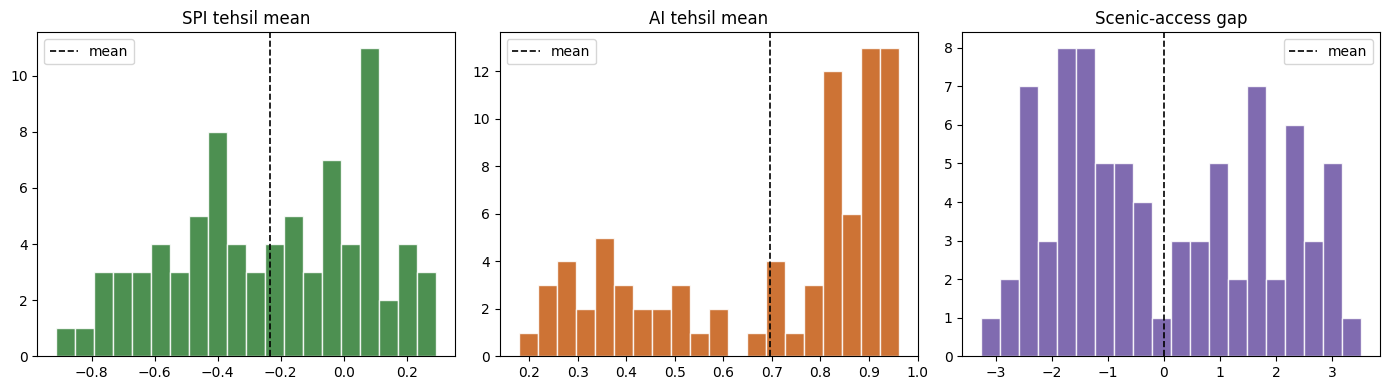

In [10]:
summary = agdf[['spi', 'ai', 'gap_index', 'area_km2']].describe().T
summary.to_csv(outputs / 'descriptive_statistics.csv')
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title, color in [
    (axes[0], 'spi',       'SPI tehsil mean',   '#2E7D32'),
    (axes[1], 'ai',        'AI tehsil mean',    '#C55A11'),
    (axes[2], 'gap_index', 'Scenic-access gap', '#6A51A3'),
]:
    ax.hist(agdf[col].dropna(), bins=20, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(agdf[col].mean(), color='black', lw=1.2, ls='--', label='mean')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
savefig('01_distributions.png')
plt.show()

### 7.2 Choropleth Maps

The gap index is high where scenic potential is above average and accessibility is below average.

Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\02_choropleth_maps.png


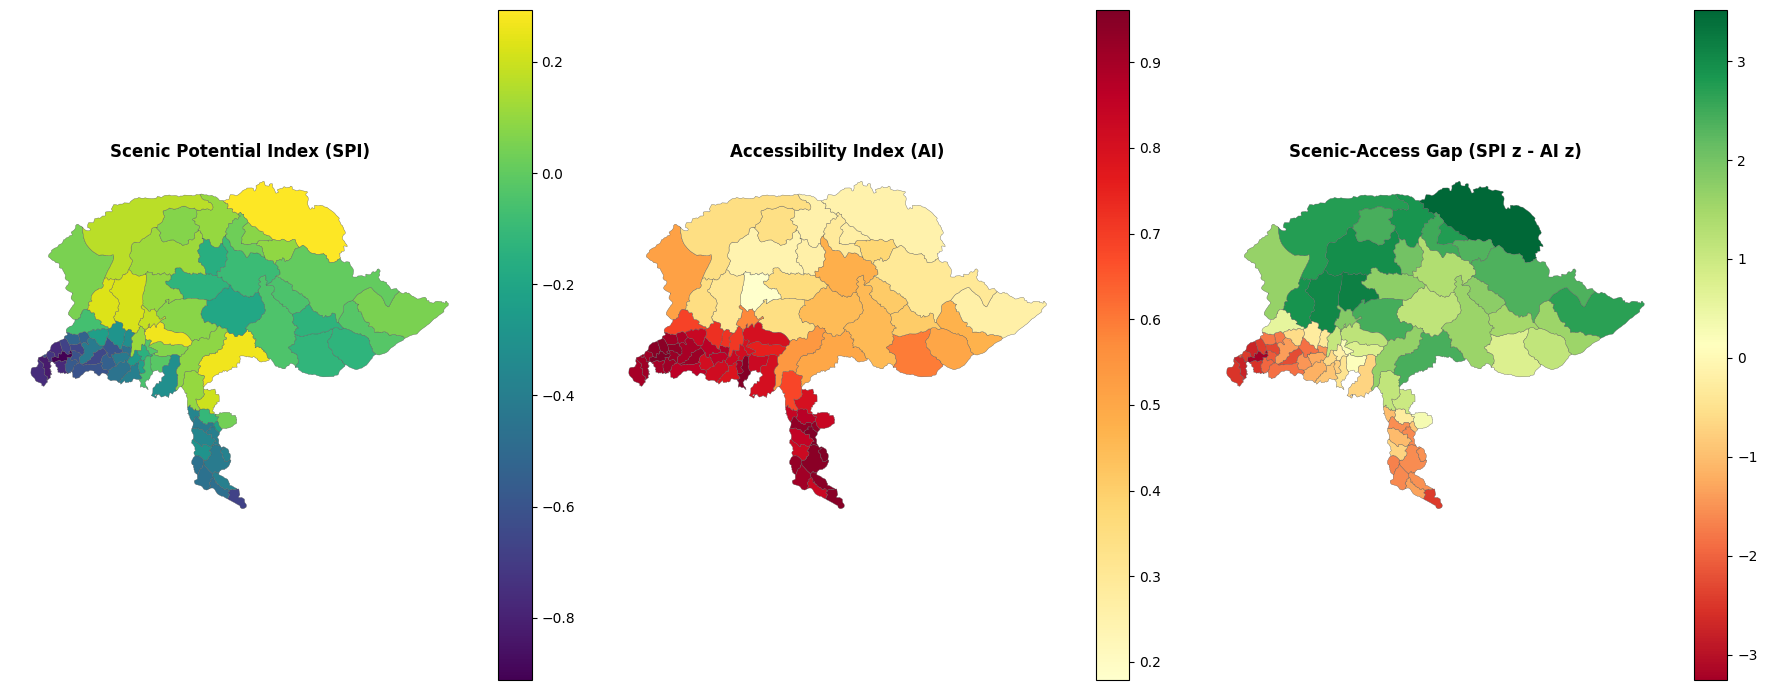

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, col, title, cmap in [
    (axes[0], 'spi',       'Scenic Potential Index (SPI)',     'viridis'),
    (axes[1], 'ai',        'Accessibility Index (AI)',         'YlOrRd'),
    (axes[2], 'gap_index', 'Scenic-Access Gap (SPI z - AI z)', 'RdYlGn'),
]:
    agdf.plot(column=col, cmap=cmap, linewidth=0.25, edgecolor='0.35', legend=True, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_axis_off()
plt.tight_layout()
savefig('02_choropleth_maps.png')
plt.show()

### 7.3 Queen Contiguity Spatial Weights

In [12]:
agdf = agdf.reset_index(drop=True)
w = Queen.from_dataframe(agdf, use_index=False)
if w.islands:
    print(f'Isolated units (no neighbors): {w.islands}')
w.transform = 'r'

agdf['n_neighbors'] = [len(w.neighbors[i]) for i in range(len(agdf))]
display(agdf['n_neighbors'].describe().to_frame('queen_neighbors').T)

,count,mean,std,min,25%,50%,75%,max
queen_neighbors,81.0,4.716049,1.70466,1.0,4.0,5.0,6.0,9.0


### 7.4 Global Spatial Autocorrelation — Moran's I

,variable,I,E[I],z,p
0,SPI,0.8146,-0.0125,11.0724,0.001
1,AI,0.8893,-0.0125,12.0112,0.001
2,Gap,0.8855,-0.0125,11.6315,0.001


Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\03_moran_i.png


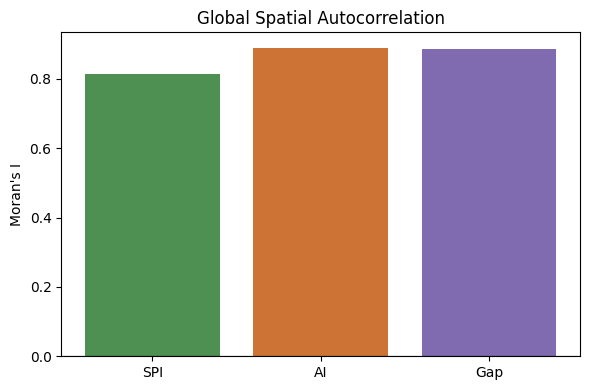

In [13]:
rows = []
for label, col in [('SPI', 'spi'), ('AI', 'ai'), ('Gap', 'gap_index')]:
    m = Moran(agdf[col].to_numpy(), w, permutations=999, two_tailed=True)
    rows.append({'variable': label, 'I': m.I, 'E[I]': m.EI, 'z': m.z_sim, 'p': m.p_sim})
moran_df = pd.DataFrame(rows)
moran_df.to_csv(outputs / 'global_moran.csv', index=False)
display(moran_df.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(moran_df['variable'], moran_df['I'],
       color=['#2E7D32', '#C55A11', '#6A51A3'], alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel("Moran's I")
ax.set_title('Global Spatial Autocorrelation')
plt.tight_layout()
savefig('03_moran_i.png')
plt.show()

### 7.5 Local Spatial Clustering — LISA

Local Moran's I classifies each tehsil as HH, LL, HL, LH, or not significant (NS). Threshold: p < 0.10, which is appropriate for moderate sample sizes.

Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\04_lisa_clusters.png


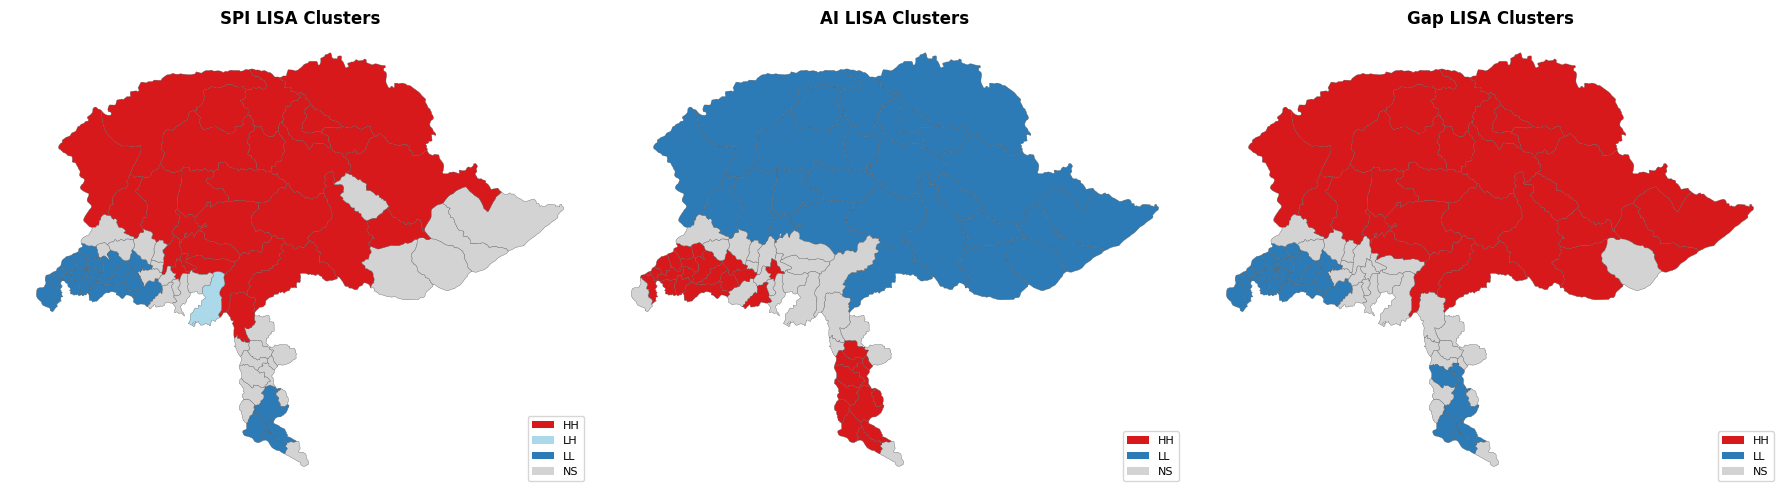

SPI: {'NS': 29, 'HH': 29, 'LL': 22, 'LH': 1}
AI: {'HH': 32, 'LL': 27, 'NS': 22}
Gap: {'NS': 28, 'HH': 28, 'LL': 25}


In [14]:
ALPHA = 0.10

for col, prefix in [('spi', 'spi'), ('ai', 'ai'), ('gap_index', 'gap')]:
    loc = Moran_Local(agdf[col].to_numpy(), w, permutations=999)
    agdf[f'{prefix}_cluster'] = lisa_labels(loc, ALPHA)
    agdf[f'{prefix}_local_I'] = loc.Is
    agdf[f'{prefix}_local_p'] = loc.p_sim

cluster_colors = {'HH': '#d7191c', 'HL': '#fdae61',
                  'LH': '#abd9e9', 'LL': '#2c7bb6', 'NS': '#d3d3d3'}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, prefix, title in [
    (axes[0], 'spi', 'SPI LISA Clusters'),
    (axes[1], 'ai',  'AI LISA Clusters'),
    (axes[2], 'gap', 'Gap LISA Clusters'),
]:
    agdf.plot(color=agdf[f'{prefix}_cluster'].map(cluster_colors),
              linewidth=0.25, edgecolor='0.35', ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_axis_off()
    handles = [Patch(facecolor=c, label=l)
               for l, c in cluster_colors.items()
               if l in set(agdf[f'{prefix}_cluster'])]
    ax.legend(handles=handles, loc='lower right', fontsize=8)
plt.tight_layout()
savefig('04_lisa_clusters.png')
plt.show()

for prefix, label in [('spi', 'SPI'), ('ai', 'AI'), ('gap', 'Gap')]:
    print(f'{label}: {agdf[f"{prefix}_cluster"].value_counts().to_dict()}')

### 7.6 Regression: SPI ~ AI

OLS regression tests whether accessibility meaningfully predicts scenic potential variation. Residuals are checked for spatial autocorrelation (Moran's I), heteroskedasticity (Breusch-Pagan), and normality (Jarque-Bera).

,metric,value
0,n,8.100000e+01
1,intercept,4.007768e-01
2,ai_coef,-9.118249e-01
3,ai_p,1.536379e-14
4,R2,5.285434e-01
5,adj_R2,5.225756e-01
6,residual_moran_I,6.361020e-01
7,residual_moran_p,1.000000e-03
8,breusch_pagan_p,3.107672e-02
9,jarque_bera_p,1.866923e-01


Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\05_regression.png


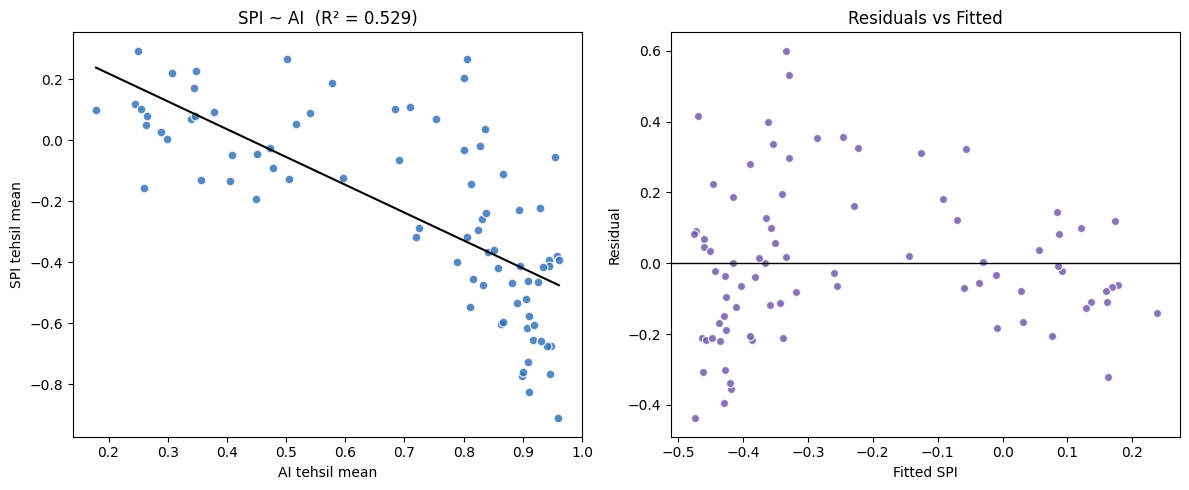

In [15]:
X = sm.add_constant(agdf['ai'].astype(float))
y = agdf['spi'].astype(float)
ols = sm.OLS(y, X).fit()

resid_moran = Moran(ols.resid.to_numpy(), w, permutations=999)
bp_lm, bp_p, _, _ = het_breuschpagan(ols.resid, ols.model.exog)
jb_stat, jb_p, _, _ = jarque_bera(ols.resid)

reg_summary = pd.DataFrame([
    ('n',                 len(agdf)),
    ('intercept',         ols.params['const']),
    ('ai_coef',           ols.params['ai']),
    ('ai_p',              ols.pvalues['ai']),
    ('R2',                ols.rsquared),
    ('adj_R2',            ols.rsquared_adj),
    ('residual_moran_I',  resid_moran.I),
    ('residual_moran_p',  resid_moran.p_sim),
    ('breusch_pagan_p',   bp_p),
    ('jarque_bera_p',     jb_p),
], columns=['metric', 'value'])
reg_summary.to_csv(outputs / 'regression_summary.csv', index=False)
display(reg_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(agdf['ai'], agdf['spi'], s=40, alpha=0.8, color='#2B6CB0', edgecolor='white')
x_line = np.linspace(agdf['ai'].min(), agdf['ai'].max(), 100)
ax.plot(x_line, ols.params['const'] + ols.params['ai'] * x_line, color='black', lw=1.5)
ax.set_title(f'SPI ~ AI  (R² = {ols.rsquared:.3f})')
ax.set_xlabel('AI tehsil mean'); ax.set_ylabel('SPI tehsil mean')

ax = axes[1]
ax.scatter(ols.fittedvalues, ols.resid, s=35, alpha=0.8, color='#6A51A3', edgecolor='white')
ax.axhline(0, color='black', lw=1)
ax.set_title('Residuals vs Fitted')
ax.set_xlabel('Fitted SPI'); ax.set_ylabel('Residual')

plt.tight_layout()
savefig('05_regression.png')
plt.show()

### 7.7 Priority Regions

Two criteria identify tehsils that warrant infrastructure investment:
- **Strict**: SPI in the top quartile *and* AI in the bottom quartile
- **Relaxed**: SPI above average *and* AI below average

Strict priority:  12 tehsils
Relaxed priority: 30 tehsils


,tehsil,spi,ai,spi_z,ai_z,gap_index,gap_rank,priority_strict,priority_relaxed,priority_lisa,spi_cluster,gap_cluster
39,GOJAL,0.293133,0.249161,1.704338,-1.812688,3.517025,1,True,True,True,HH,HH
54,KANDIA,0.097723,0.178879,1.072579,-2.097671,3.170250,2,True,True,True,HH,HH
71,BAHRAIN,0.219034,0.307003,1.464776,-1.578149,3.042925,3,True,True,True,HH,HH
33,GUPIS,0.117111,0.244178,1.135262,-1.832895,2.968157,4,True,True,True,HH,HH
79,SHARINGAL,0.227252,0.348056,1.491344,-1.411686,2.903030,5,True,True,True,HH,HH
34,ISHKOMEN,0.102651,0.254330,1.088511,-1.791730,2.880242,6,True,True,True,HH,HH
38,ALIABAD,0.080701,0.264915,1.017548,-1.748809,2.766357,7,True,True,True,HH,HH
52,MASTUJ,0.169984,0.343919,1.306199,-1.428461,2.734660,8,True,True,True,HH,HH
32,MASHABRUM,0.049783,0.263824,0.917590,-1.753231,2.670821,9,True,True,True,NS,HH
41,NAGAR-II,0.028111,0.289463,0.847525,-1.649271,2.496796,10,False,True,True,HH,HH


Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\06_priority_regions.png


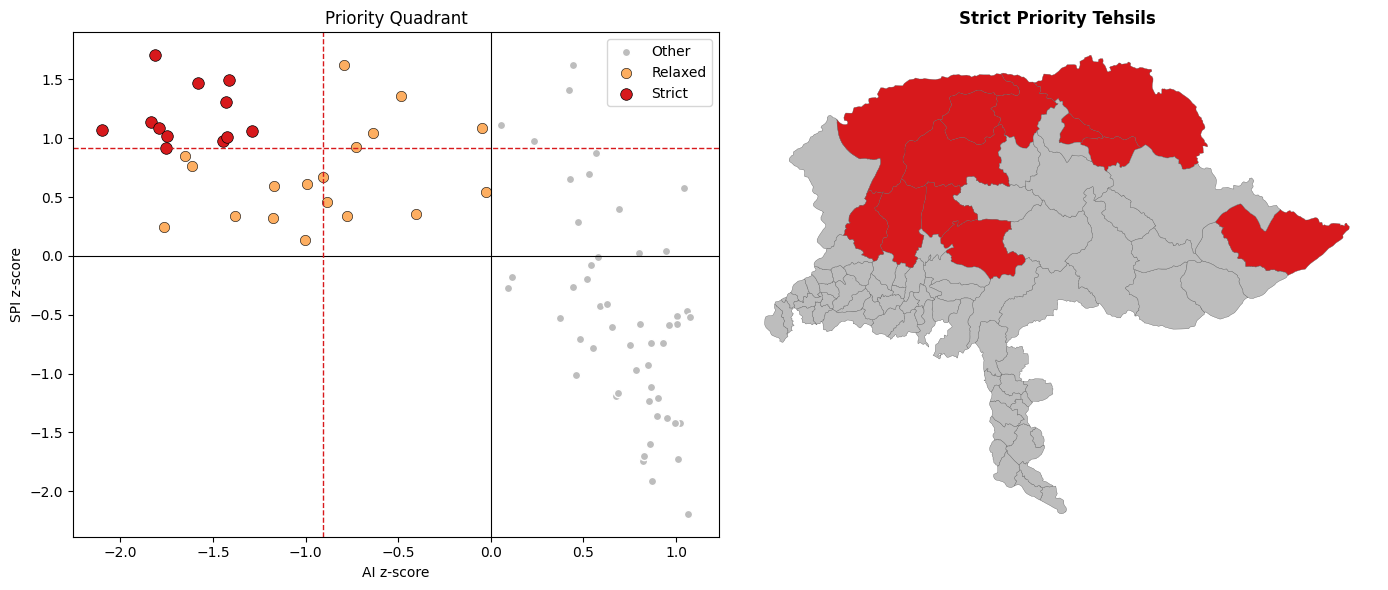

In [16]:
spi_q75 = agdf['spi_z'].quantile(0.75)
ai_q25  = agdf['ai_z'].quantile(0.25)

agdf['priority_strict']  = (agdf['spi_z'] >= spi_q75) & (agdf['ai_z'] <= ai_q25)
agdf['priority_relaxed'] = (agdf['spi_z'] > 0) & (agdf['ai_z'] < 0)
agdf['priority_lisa']    = (agdf['gap_cluster'].isin(['HH', 'HL']) &
                            (agdf['gap_local_p'] <= ALPHA))

priority_cols = [
    'tehsil', 'spi', 'ai', 'spi_z', 'ai_z', 'gap_index', 'gap_rank',
    'priority_strict', 'priority_relaxed', 'priority_lisa', 'spi_cluster', 'gap_cluster',
]
priority_table = agdf[priority_cols].sort_values('gap_index', ascending=False)
priority_table.to_csv(outputs / 'priority_regions.csv', index=False)

print(f'Strict priority:  {agdf.priority_strict.sum()} tehsils')
print(f'Relaxed priority: {agdf.priority_relaxed.sum()} tehsils')
display(priority_table.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(agdf['ai_z'], agdf['spi_z'], color='#bdbdbd', s=35, edgecolor='white', label='Other')
mask_r = agdf['priority_relaxed'] & ~agdf['priority_strict']
ax.scatter(agdf.loc[mask_r, 'ai_z'], agdf.loc[mask_r, 'spi_z'],
           color='#fdae61', s=55, edgecolor='k', lw=0.4, label='Relaxed')
ax.scatter(agdf.loc[agdf['priority_strict'], 'ai_z'],
           agdf.loc[agdf['priority_strict'], 'spi_z'],
           color='#d7191c', s=70, edgecolor='k', lw=0.5, label='Strict')
ax.axhline(0, color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8)
ax.axhline(spi_q75, color='#d7191c', ls='--', lw=1)
ax.axvline(ai_q25,  color='#d7191c', ls='--', lw=1)
ax.set_xlabel('AI z-score'); ax.set_ylabel('SPI z-score')
ax.set_title('Priority Quadrant'); ax.legend()

ax = axes[1]
agdf.plot(color=agdf['priority_strict'].map({True: '#d7191c', False: '#bdbdbd'}),
          linewidth=0.25, edgecolor='0.35', ax=ax)
ax.set_title('Strict Priority Tehsils', fontweight='bold'); ax.set_axis_off()

plt.tight_layout()
savefig('06_priority_regions.png')
plt.show()

### 7.8 SPI Component Contributions

Tehsil-level means for TRI, forest, water, and snow are extracted from the raw input rasters and correlated with tehsil SPI to show which landscape features drive scenic potential.

In [17]:
comp_raster_paths = {
    'tri_mean': data_paths['tri'],
    'forest_pct': data_paths['forest_mask'],
    'water_pct': data_paths['water_mask'],
    'snow_pct': data_paths['snow_frequency'],
}


def raster_zonal_mean(raster_path, zones, label):

    with rasterio.open(raster_path) as src:

        arr = src.read(1).astype('float32')

        unique_vals = np.unique(arr[~np.isnan(arr)])

        # avoid treating valid 0s in binary masks as nodata
        if not np.array_equal(unique_vals, [0, 1]):

            if src.nodata is not None:
                arr[arr == src.nodata] = np.nan

        crs = src.crs
        tf = src.transform

    zones = zones.to_crs(crs) if zones.crs != crs else zones

    rows = []

    for _, row in zones.iterrows():

        mask = geometry_mask(
            [row.geometry],
            out_shape=arr.shape,
            transform=tf,
            invert=True
        )

        vals = arr[mask & np.isfinite(arr)]

        rows.append({
            'tehsil': row[name_col] if name_col else str(row.name),
            label: np.nanmean(vals) if vals.size else np.nan
        })

    return pd.DataFrame(rows)


comp_df = None

for label, path in comp_raster_paths.items():

    df = raster_zonal_mean(path, tehsils, label)

    comp_df = (
        df if comp_df is None
        else comp_df.merge(df, on='tehsil', how='outer')
    )


analysis_gdf = (
    agdf
    .drop(columns=list(comp_raster_paths.keys()), errors='ignore')
    .merge(comp_df, on='tehsil', how='left')
)

component_cols = list(comp_raster_paths.keys())

for col in component_cols + ['spi']:
    analysis_gdf[col] = pd.to_numeric(
        analysis_gdf[col],
        errors='coerce'
    )


corr_rows = []

for col in component_cols:

    valid = analysis_gdf[[col, 'spi']].dropna()

    if valid[col].nunique() <= 1:
        continue

    model = sm.OLS(
        valid['spi'],
        sm.add_constant(valid[col])
    ).fit()

    corr_rows.append({
        'component': col,
        'pearson_r': valid[[col, 'spi']].corr('pearson').iloc[0, 1],
        'spearman_rho': valid[[col, 'spi']].corr('spearman').iloc[0, 1],
        'ols_slope': model.params[col],
        'ols_slope_p': model.pvalues[col],
        'ols_r_squared': model.rsquared,
    })


component_corr = pd.DataFrame(corr_rows)

component_corr.to_csv(
    outputs / 'component_spi_correlations.csv',
    index=False
)

display(component_corr)

,component,pearson_r,spearman_rho,ols_slope,ols_slope_p,ols_r_squared
0,tri_mean,0.851878,0.863505,0.019149,6.754315e-24,0.725695
1,forest_pct,0.114805,0.007023,0.255252,3.074619e-01,0.013180
2,water_pct,0.623056,0.694664,1.463026,5.251046e-10,0.388199
3,snow_pct,0.804455,0.866034,2.298225,1.490333e-19,0.647148


### 7.9 Sensitivity Analysis

Four alternative weighting schemes are tested at the tehsil level to check whether priority rankings are robust to the choice of SPI weights. Relief weight (0.35) is approximated by TRI since TPI zonal means are not extracted here.

In [ ]:
for col in component_cols:
    analysis_gdf[f'{col}_z'] = zscore(analysis_gdf[col])

weight_sets = {
    'proposal':         {'tri_mean_z': 0.35, 'forest_pct_z': 0.25, 'water_pct_z': 0.20, 'snow_pct_z': 0.20},
    'equal':            {'tri_mean_z': 0.25, 'forest_pct_z': 0.25, 'water_pct_z': 0.25, 'snow_pct_z': 0.25},
    'terrain_emphasis': {'tri_mean_z': 0.50, 'forest_pct_z': 0.20, 'water_pct_z': 0.15, 'snow_pct_z': 0.15},
    'veg_water_emph':   {'tri_mean_z': 0.30, 'forest_pct_z': 0.30, 'water_pct_z': 0.25, 'snow_pct_z': 0.15},
}

sens_rows = []

priority_freq = np.zeros(len(analysis_gdf))

for name, wts in weight_sets.items():

    z_cols = [c for c in wts if c in analysis_gdf.columns]

    if not z_cols:
        continue

    analysis_gdf[f'spi_alt_{name}'] = sum(
        analysis_gdf[c] * wts[c]
        for c in z_cols
    )

    corr = (
        analysis_gdf[['spi', f'spi_alt_{name}']]
        .dropna()
        .corr()
        .iloc[0, 1]
    )

    alt_z = zscore(analysis_gdf[f'spi_alt_{name}'])

    priority_freq += (
        (alt_z >= alt_z.quantile(0.75))
        & analysis_gdf['priority_strict']
    ).astype(float)

    sens_rows.append({
        'weight_set': name,
        'corr_with_current_spi': corr
    })

analysis_gdf['priority_frequency'] = priority_freq

sens_df = pd.DataFrame(sens_rows)

sens_df.to_csv(
    outputs / 'sensitivity_analysis.csv',
    index=False
)

display(sens_df)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    sens_df['weight_set'],
    sens_df['corr_with_current_spi'],
    color='#2E7D32',
    alpha=0.85
)

axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Pearson r with current SPI')
axes[0].set_title('SPI Weighting Sensitivity')
axes[0].tick_params(axis='x', rotation=20)

analysis_gdf.plot(
    column='priority_frequency',
    cmap='YlOrRd',
    linewidth=0.25,
    edgecolor='0.35',
    legend=True,
    ax=axes[1]
)

axes[1].set_title('Priority Stability Across Weighting Schemes')
axes[1].set_axis_off()

plt.tight_layout()

savefig('07_sensitivity.png')

plt.show()

KeyError: 'tri_mean'

### 7.10 Bivariate SPI-AI Map

Saved: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\08_bivariate_map.png


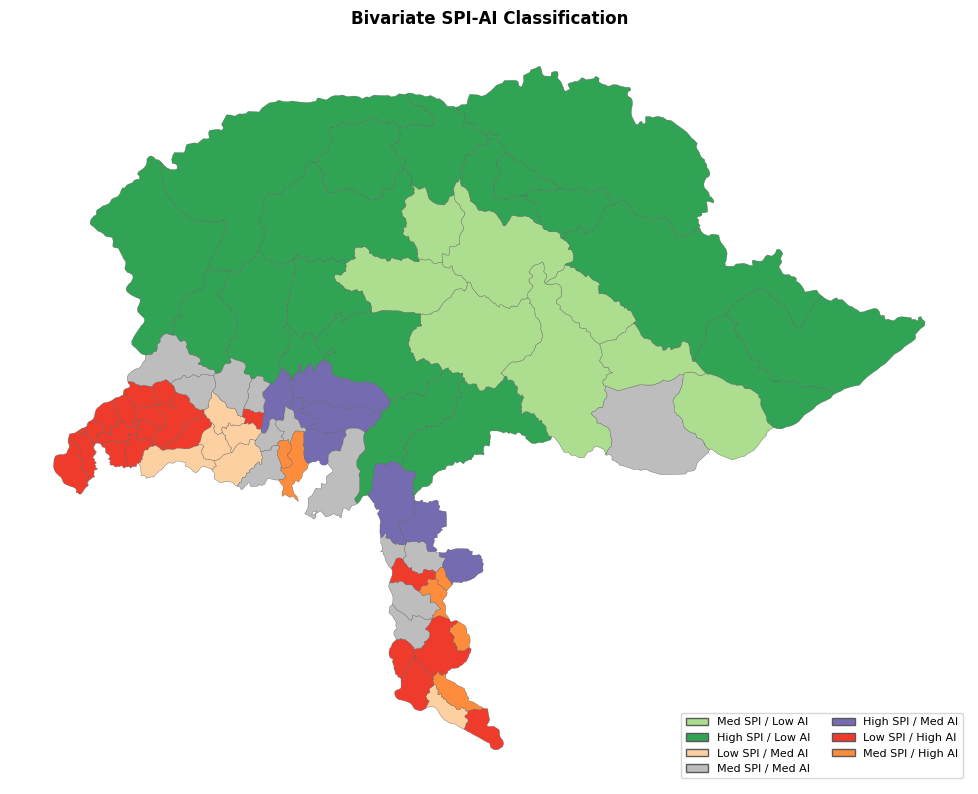

In [ ]:
def tertile(s):

    q1, q2 = s.quantile([1/3, 2/3])

    return pd.cut(
        s,
        bins=[-np.inf, q1, q2, np.inf],
        labels=['Low', 'Med', 'High']
    )


analysis_gdf['spi_class'] = tertile(analysis_gdf['spi'])

analysis_gdf['ai_class'] = tertile(analysis_gdf['ai'])

analysis_gdf['biv_class'] = (
    analysis_gdf['spi_class'].astype(str)
    + ' SPI / '
    + analysis_gdf['ai_class'].astype(str)
    + ' AI'
)


bivar_colors = {
    'Low SPI / Low AI':  '#d9f0d3',
    'Med SPI / Low AI':  '#addd8e',
    'High SPI / Low AI': '#31a354',

    'Low SPI / Med AI':  '#fdd0a2',
    'Med SPI / Med AI':  '#bdbdbd',
    'High SPI / Med AI': '#756bb1',

    'Low SPI / High AI': '#ef3b2c',
    'Med SPI / High AI': '#fd8d3c',
    'High SPI / High AI':'#54278f',
}


fig, ax = plt.subplots(figsize=(10, 8))

analysis_gdf.plot(
    color=analysis_gdf['biv_class']
    .map(bivar_colors)
    .fillna('#cccccc'),

    linewidth=0.25,
    edgecolor='0.35',
    ax=ax
)

ax.set_title(
    'Bivariate SPI-AI Classification',
    fontweight='bold'
)

ax.set_axis_off()

handles = [
    Patch(facecolor=c, edgecolor='0.35', label=l)
    for l, c in bivar_colors.items()
    if l in set(analysis_gdf['biv_class'])
]

ax.legend(
    handles=handles,
    loc='lower right',
    fontsize=8,
    ncol=2
)

plt.tight_layout()

savefig('08_bivariate_map.png')

plt.show()

## 8. Export Final Dataset

In [ ]:
out_geojson  = outputs   / 'tehsil_spi_ai_analysis.geojson'
out_csv      = outputs   / 'tehsil_spi_ai_analysis.csv'

proc_geojson = processed / 'final_tehsil_spi_ai_analysis.geojson'
proc_csv     = processed / 'final_tehsil_spi_ai_analysis.csv'


analysis_gdf.to_file(
    out_geojson,
    driver='GeoJSON'
)

analysis_gdf.to_file(
    proc_geojson,
    driver='GeoJSON'
)

analysis_gdf.drop(
    columns='geometry'
).to_csv(
    out_csv,
    index=False
)

analysis_gdf.drop(
    columns='geometry'
).to_csv(
    proc_csv,
    index=False
)


report = {
    'n_tehsils':        int(len(analysis_gdf)),
    'spi_mean':         float(analysis_gdf['spi'].mean()),
    'ai_mean':          float(analysis_gdf['ai'].mean()),
    'global_moran':     moran_df.to_dict(orient='records'),
    'priority_strict':  int(analysis_gdf['priority_strict'].sum()),
    'priority_relaxed': int(analysis_gdf['priority_relaxed'].sum()),
    'outputs_dir':      str(outputs),
}


with open(outputs / 'analysis_summary.json', 'w') as f:
    json.dump(report, f, indent=2)


print('Exports complete:')

for p in [
    out_csv,
    proc_csv,
    out_geojson,
    proc_geojson,
    outputs / 'analysis_summary.json'
]:
    print(f'  {p}')

Exports complete:
  c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\tehsil_spi_ai_analysis.csv
  c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\processed\final_tehsil_spi_ai_analysis.csv
  c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\tehsil_spi_ai_analysis.geojson
  c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\processed\final_tehsil_spi_ai_analysis.geojson
  c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\analysis_summary.json
